In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import albumentations as A
import shutil

In [3]:
dataset_path = "../data"

image_paths = []
labels = []

classes = os.listdir(dataset_path)

for cls in classes:
    class_path = os.path.join(dataset_path, cls)

    subfolders = os.listdir(class_path)
    img_folder = os.path.join(class_path, subfolders[0])

    for img_name in os.listdir(img_folder):
        img_path = os.path.join(img_folder, img_name)

        image_paths.append(img_path)
        labels.append(cls)

print("Total Images:", len(image_paths))
print("Classes:", classes)

Total Images: 2688
Classes: ['Blowhole', 'Break', 'Crack', 'Fray', 'Free', 'Uneven']


In [4]:
clean_paths = []
clean_labels = []

for path, label in zip(image_paths, labels):

    try:
        img = cv2.imread(path)

        if img is None:
            continue

        clean_paths.append(path)
        clean_labels.append(label)

    except:
        continue

print("Valid Images:", len(clean_paths))

Valid Images: 2688


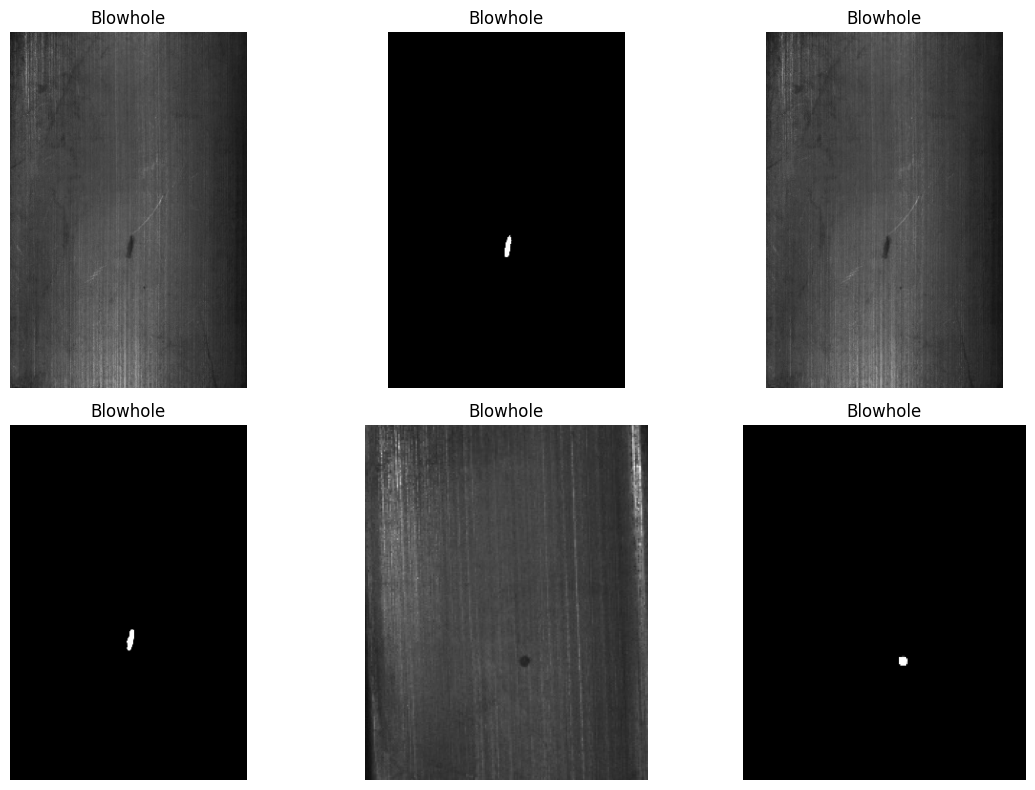

In [5]:
plt.figure(figsize=(12,8))

for i in range(6):

    img = cv2.imread(clean_paths[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(clean_labels[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
IMG_SIZE = 640

def resize_image(img):
    return cv2.resize(img, (IMG_SIZE, IMG_SIZE))

In [7]:
def gaussian_denoise(img):
    return cv2.GaussianBlur(img, (5,5), 0)

In [8]:
def median_denoise(img):
    return cv2.medianBlur(img, 5)

In [9]:
def histogram_equalization(img):

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    equalized = cv2.equalizeHist(gray)

    return equalized

In [10]:
def apply_clahe(img):

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    enhanced = clahe.apply(gray)

    return enhanced

In [11]:
def threshold_segmentation(img):

    _, thresh = cv2.threshold(
        img,
        120,
        255,
        cv2.THRESH_BINARY
    )

    return thresh

In [12]:
def canny_edges(img):

    edges = cv2.Canny(
        img,
        100,
        200
    )

    return edges

In [13]:
def morphology(img):

    kernel = np.ones((3,3), np.uint8)

    opening = cv2.morphologyEx(
        img,
        cv2.MORPH_OPEN,
        kernel
    )

    closing = cv2.morphologyEx(
        opening,
        cv2.MORPH_CLOSE,
        kernel
    )

    return closing

In [14]:
def extract_contours(img):

    contours, _ = cv2.findContours(
        img,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    contour_img = np.zeros_like(img)

    cv2.drawContours(
        contour_img,
        contours,
        -1,
        (255,255,255),
        2
    )

    return contour_img, contours

In [15]:
sample_path = clean_paths[0]

img = cv2.imread(sample_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# resize
img = resize_image(img)

# denoise
gaussian = gaussian_denoise(img)

# CLAHE
clahe = apply_clahe(gaussian)

# segmentation
thresh = threshold_segmentation(clahe)

# edges
edges = canny_edges(thresh)

# morphology
morph = morphology(edges)

# contours
contour_img, contours = extract_contours(morph)

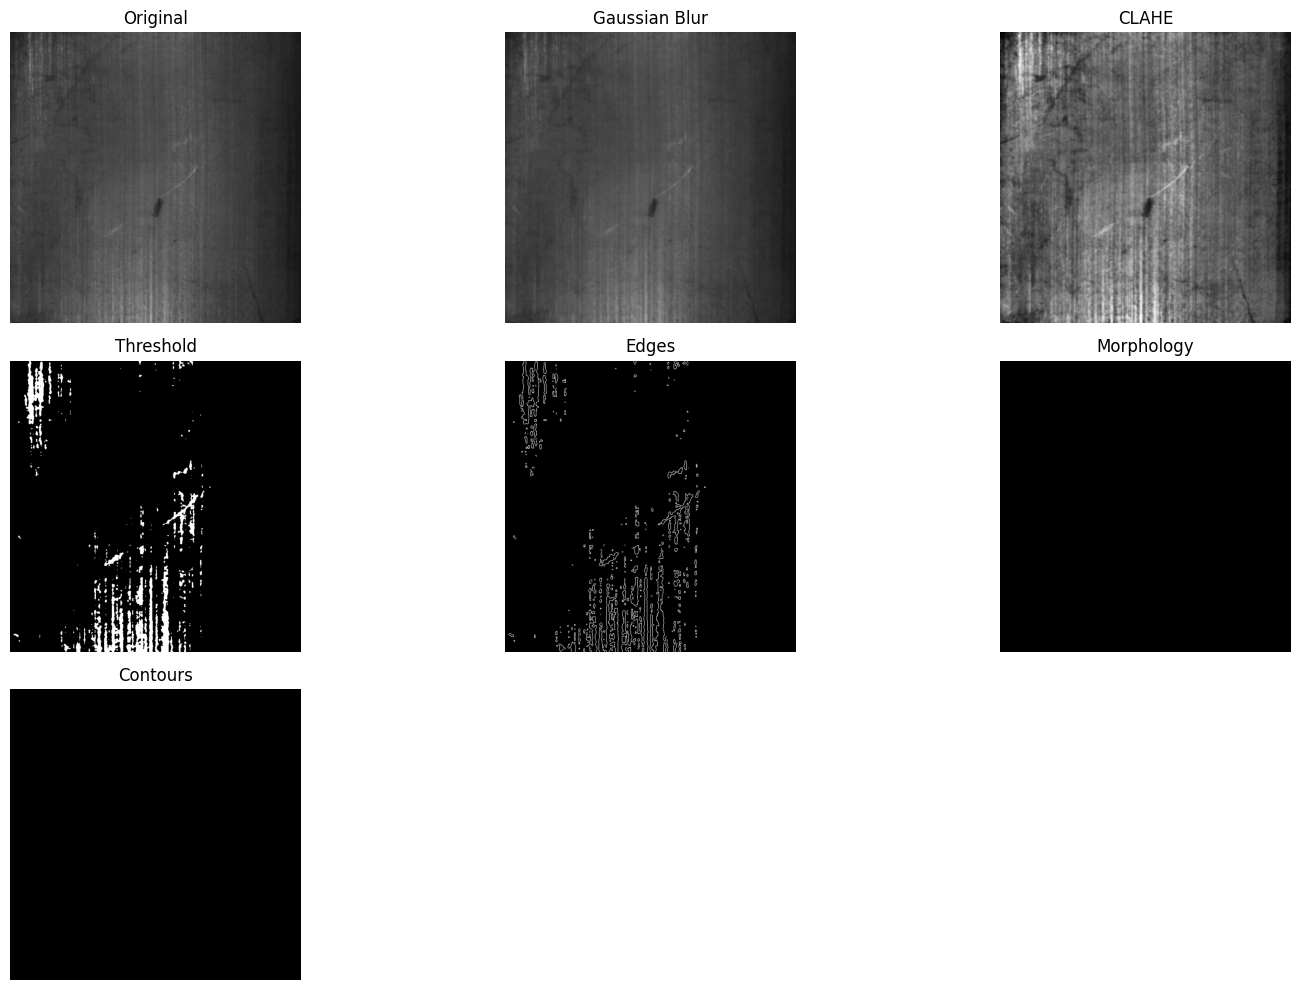

In [16]:
titles = [
    "Original",
    "Gaussian Blur",
    "CLAHE",
    "Threshold",
    "Edges",
    "Morphology",
    "Contours"
]

images = [
    img,
    gaussian,
    clahe,
    thresh,
    edges,
    morph,
    contour_img
]

plt.figure(figsize=(15,10))

for i in range(len(images)):

    plt.subplot(3,3,i+1)

    if len(images[i].shape) == 2:
        plt.imshow(images[i], cmap='gray')
    else:
        plt.imshow(images[i])

    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
transform = A.Compose([

    A.HorizontalFlip(p=0.5),

    A.Rotate(limit=20, p=0.5),

    A.RandomBrightnessContrast(p=0.5),

    A.GaussNoise(p=0.3)

])

In [18]:
X_train, X_temp, y_train, y_temp = train_test_split(
    clean_paths,
    clean_labels,
    test_size=0.3,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 1881
Validation: 403
Test: 404


In [19]:
base_dir = "../dataset_yolo"

os.makedirs(base_dir + "/images/train", exist_ok=True)
os.makedirs(base_dir + "/images/val", exist_ok=True)
os.makedirs(base_dir + "/images/test", exist_ok=True)

os.makedirs(base_dir + "/labels/train", exist_ok=True)
os.makedirs(base_dir + "/labels/val", exist_ok=True)
os.makedirs(base_dir + "/labels/test", exist_ok=True)

print("YOLO folders created")

YOLO folders created


In [20]:
def copy_images(image_list, split):

    for img_path in image_list:

        filename = os.path.basename(img_path)

        dest_path = os.path.join(
            base_dir,
            f"images/{split}/{filename}"
        )

        shutil.copy(img_path, dest_path)

copy_images(X_train, "train")
copy_images(X_val, "val")
copy_images(X_test, "test")

print("Images copied")

Images copied
